# Feature Importance Analysis with Integrated Gradients

In [112]:
from pydoc import locate

from captum.attr import IntegratedGradients
import lightning as L
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
import pandas as pd
from rich.progress import track
import torch
from torch import Tensor, nn
import wandb
import xarray as xr

from deeprec.data import DeepRecDataModule
from deeprec.utils import ROOT_DIR, wandb_checkpoint_download

In [113]:
set_matplotlib_formats("retina")
plt.style.use(ROOT_DIR / "config/style_paper.mplstyle")

## Load model weights

In [114]:
wandb_project = "deeprec-paper_ensembles"
run_id = "6pz8pwa4"
alias = "best"
# Download checkpoint
ckpt_file = wandb_checkpoint_download(project=wandb_project, run_id=run_id, alias=alias)
# Download model config
api = wandb.Api()
run = api.run(f"{wandb_project}/{run_id}")
config = run.config

wandb:   1 of 1 files downloaded.  


In [115]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"{device = }")

device = device(type='mps')


In [116]:
def set_bn_eval(module: nn.Module) -> None:
    """Recursively set all BatchNorm layers to eval mode."""
    if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
        module.eval()
    for child in module.children():
        set_bn_eval(child)

In [117]:
# Model creation
model_class = locate(config["model"]["class_path"])
if issubclass(model_class, L.LightningModule):
    model = model_class.load_from_checkpoint(ckpt_file, **config["model"])
else:
    raise TypeError(f"Provided class_path '{model_class}' is not a LightningModule.")
model.to(device)
# Keep model in training mode
model.train()
# But freeze BatchNorm layers
set_bn_eval(model)

In [118]:
class ModelWrapper(L.LightningModule):
    """Wraps the model to accept tuples instead of a dictionary.

    Only returns TWSA (mu), not the uncertainty (b)."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, xt: Tensor, xm: Tensor, xv: Tensor):
        # Manually set requires_grad to True as we do not use PyTorch Lightning
        xt = xt.requires_grad_()
        xm = xm.requires_grad_()
        xv = xv.requires_grad_()
        # forward pass
        out = self.model(tensor_inputs=xt, matrix_inputs=xm, vector_inputs=xv)

        # Only return the mean (first output)
        mu_idx = 0
        return out[:, mu_idx]

In [119]:
wrapped = ModelWrapper(model)

## Calculate Integrated Gradients with Captum

In [120]:
import numpy as np
from torch.utils.data import DataLoader, Dataset, Subset

from deeprec.data.dataset import DeepRecDataset

In [121]:
# Data creation
dm = DeepRecDataModule(**config["data"])
# Get inputs during train time (range for baseline calc)
times_train = dm._time_train
start, end = times_train[0], times_train[-1]
inputs = dm._inputs.sel(time=slice(start, end))

# Get tensors for the unchanged inputs
# We use the predict stage as it leaves inputs in original order
dm._inputs = inputs
dm.setup("predict")
data_inputs = DeepRecDataset(
    dm._predict_tensors,
    space_window=dm._space_window,
    time_window=dm._time_window,
)

DataModule: Preparing predict tensors...


In [122]:
# Define climatology and static baseline inputs
inputs_clim = [
    "era5_d2m",
    "era5_t2m",
    "era5_e",
    "era5_lai_hv",
    "era5_lai_lv",
    "era5_pev",
    "era5_sro",
    "era5_ssro",
    "era5_sp",
    "era5_tp",
    "era5_swvl1",
    "era5_swvl2",
    "era5_swvl3",
    "era5_swvl4",
]
inputs_static = [
    "nvec_x",
    "nvec_y",
    "nvec_z",
    "cell_area",
    "cropland_irrigated",
    "cropland_rainfed",
    "pastures",
    "urbanareas",
    "lakes",
    "year_sin",
    "year_cos",
    "year2_sin",
    "year2_cos",
    "year2_cos",
    "oni",
]


In [123]:
# # Calculate baseline for all inputs over train period within area mask
# mask = dm._mask
# inputs_baseline = inputs.copy(deep=True)
# # Month selector with time dimension
# time_index = inputs.get_index("time")
# months = time_index.month
# selector = xr.DataArray(months, coords=[time_index])
# # Replace spatiotemporal inputs with their per-grid-cell monthly climatology
# for inp in inputs_clim:
#     da = inputs_baseline[inp]
#     # Dims: (month, lat, lon)
#     clim = da.groupby("time.month").mean(dim=["time"], skipna=True)
#     # Dims: (time, lat, lom)
#     clim_time = clim.sel(month=selector).drop_vars("month")
#     inputs_baseline[inp] = clim_time
# # Replace static inputs with their per-grid-cell mean
# for inp in inputs_static:
#     da = inputs_baseline[inp]
#     if "lat" in da.dims or "lon" in da.dims:
#         da = da.where(mask == 1)
#     mean = da.mean().broadcast_like(inputs_baseline[inp])
#     inputs_baseline[inp] = mean

# # Use a zero baseline
inputs_baseline = xr.zeros_like(inputs)


In [124]:
# Create a baseline dataloader
dm._inputs = inputs_baseline
dm.setup("predict")
data_baseline = DeepRecDataset(
    dm._predict_tensors,
    space_window=dm._space_window,
    time_window=dm._time_window,
)

DataModule: Preparing predict tensors...


In [125]:
def create_sampled_dataloader(
    dataset: Dataset,
    sample_size: int,
    batch_size: int,
    seed: int = 42,
    **dataloader_kwargs,
) -> DataLoader:
    """Create a dataloader with randomly sampled subset of data.

    More efficient than iterating through all batches.
    """
    rng = np.random.default_rng(seed)

    # Randomly select sample indices from dataset
    total_dataset_size = len(dataset)
    selected_indices = rng.choice(
        total_dataset_size,
        size=min(sample_size, total_dataset_size),
        replace=False,
    )

    # Create subset
    subset = Subset(dataset, selected_indices)

    # Create new dataloader
    sampled_dataloader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        **dataloader_kwargs,
    )

    return sampled_dataloader

In [126]:
assert len(data_inputs) == len(data_baseline)

print(f"Total sample size: {len(data_inputs):_}")

Total sample size: 13_277_925


In [127]:
SAMPLE_SIZE = 20_000
BATCH_SIZE = 256
sample_dl_inputs = create_sampled_dataloader(
    data_inputs,
    sample_size=SAMPLE_SIZE,
    batch_size=BATCH_SIZE,
    seed=3141,
)
sample_dl_baseline = create_sampled_dataloader(
    data_baseline,
    sample_size=SAMPLE_SIZE,
    batch_size=BATCH_SIZE,
    seed=3141,
)

In [128]:
assert len(sample_dl_inputs) == len(sample_dl_baseline)

print(f"{len(sample_dl_inputs)}")

79


In [129]:
def dict_to_tuple(dict_: dict[str, Tensor], device: torch.device) -> tuple[Tensor, Tensor, Tensor]:
    input_order = ("tensor_inputs", "matrix_inputs", "vector_inputs")
    return tuple(dict_[inp].to(device) for inp in input_order)

In [130]:
ig = IntegratedGradients(wrapped)

In [131]:
COMPUTE = False
att_t_mean_list = []
att_m_mean_list = []
att_v_mean_list = []
if COMPUTE:
    for b_input, b_baseline in track(zip(sample_dl_inputs, sample_dl_baseline)):
        b_input = dict_to_tuple(b_input["inputs"], device)
        b_baseline = dict_to_tuple(b_baseline["inputs"], device)

        # Calculate attributions
        attributions = ig.attribute(
            b_input,
            baselines=b_baseline,
            method="riemann_trapezoid",
            n_steps=50,
            internal_batch_size=256,
        )

        att_t, att_m, att_v = attributions
        # Sum over time, lat, lon
        att_t_mean = att_t.sum(dim=[-3, -2, -1]).cpu().numpy()
        # Sum over time, mean over lat, lon
        # att_t_mean = att_t.sum(dim=-1).mean(dim=[-2, -1]).cpu().numpy()
        # Sum over lat, lon
        att_m_mean = att_m.sum(dim=[-2, -1]).cpu().numpy()
        # Mean over lat, lon
        # att_m_mean = att_m.mean(dim=[-2, -1]).cpu().numpy()
        # Sum over time
        att_v_mean = att_v.sum(dim=-1).cpu().numpy()

        att_t_mean_list.append(att_t_mean)
        att_m_mean_list.append(att_m_mean)
        att_v_mean_list.append(att_v_mean)

In [132]:
if COMPUTE:
    # t_elems = att_t.size(-3) * att_t.size(-2) * att_t.size(-1)
    # m_elems = att_m.size(-2) * att_m.size(-1)
    # v_elems = att_v.size(-1)
    t_elems = 1
    m_elems = 1
    v_elems = 1
    att_t_mean = np.concat(att_t_mean_list) / t_elems
    att_m_mean = np.concat(att_m_mean_list) / m_elems
    att_v_mean = np.concat(att_v_mean_list) / v_elems

    # Save
    np.save("att_t.npy", att_t_mean)
    np.save("att_m.npy", att_m_mean)
    np.save("att_v.npy", att_v_mean)

att_t_mean = np.load("att_t.npy")
att_m_mean = np.load("att_m.npy")
att_v_mean = np.load("att_v.npy")

## Box plots

In [133]:
rename = {
    "era5_d2m": "Dewpoint temp 2m",
    "era5_t2m": "Temperature 2m",
    "era5_e": "Evaporation",
    "era5_lai_hv": "LAI, high",
    "era5_lai_lv": "LAI, low",
    "era5_pev": "Potential evaporation",
    "era5_ro": "Runoff",
    "era5_ssro": "Sub-surface runoff",
    "era5_sro": "Surface runoff",
    "era5_sp": "Surface pressure",
    "era5_tp": "Total precipitation",
    "era5_swvl1": "Soil water, lyr. 1",
    "era5_swvl2": "Soil water, lyr. 2",
    "era5_swvl3": "Soil water, lyr. 3",
    "era5_swvl4": "Soil water, lyr. 4",
    "cropland_irrigated": "Cropland irrigated",
    "cropland_rainfed": "Cropland rainfed",
    "pastures": "Pastures",
    "urbanareas": "Urban areas",
    "lakes": "Lakes",
    "cell_area": "Cell area",
    "nvec_x": "n-vector, X",
    "nvec_y": "n-vector, Y",
    "nvec_z": "n-vector, Z",
    "year_cos": "Periodic year, cosine",
    "year_sin": "Periodic year, sine",
    "year2_cos": "Periodic half-year, cosine",
    "year2_sin": "Periodic half-year, sine",
    "oni": "Oceanic Niño Index (ONI)",
}


In [134]:
def plot_attributions(data: np.ndarray, labels: list[str], ax: plt.Axes) -> None:
    medians = np.median(data, axis=0)
    abs_medians = np.abs(medians)
    order = np.argsort(medians)
    data = data[:, order]
    labels = [labels[i] for i in order]
    labels = [rename[label] for label in labels]

    ax.axvline(0, color="lightgray", linewidth=1.2, zorder=-100)
    bplot = ax.boxplot(
        data,
        showfliers=False,
        orientation="horizontal",
        tick_labels=labels,
        patch_artist=True,
    )
    for patch in bplot["boxes"]:
        patch.set(facecolor="lightgray", linewidth=0.8)
    for patch in bplot["caps"]:
        patch.set(linewidth=0.8)
    for patch in bplot["whiskers"]:
        patch.set(linewidth=0.8)
    for line in bplot["medians"]:
        line.set(color="tab:orange", linewidth=1.2)
    ax.set(xlabel="Integrated gradient", ylabel=None)
    ax.axes.grid()

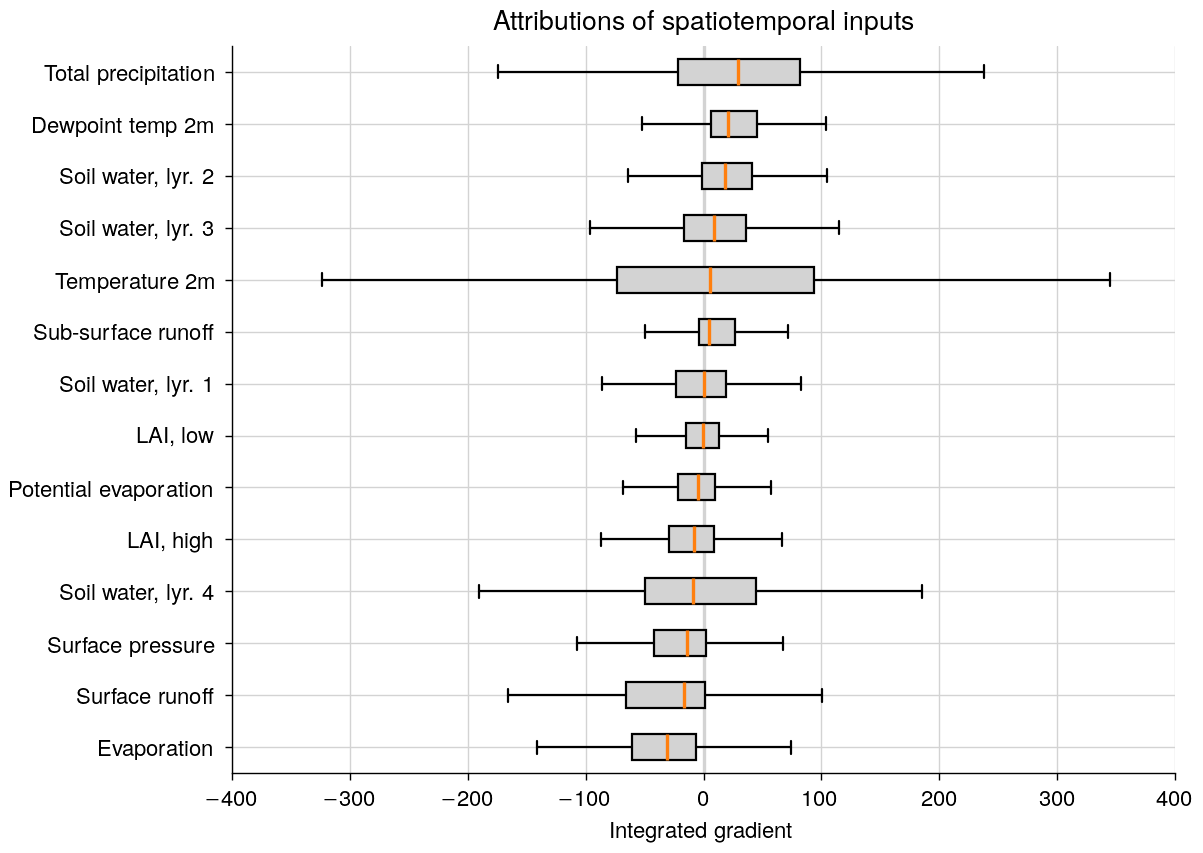

In [135]:
data = att_t_mean
labels = dm._tensor_input_vars
height = (len(labels) + 3) / 4
fig, ax = plt.subplots(figsize=(6, height))
plot_attributions(data, labels, ax=ax)
# ax.set(xlim=(-0.8, 0.8), title="Attributions of spatiotemporal inputs");
ax.set(xlim=(-400, 400), title="Attributions of spatiotemporal inputs");

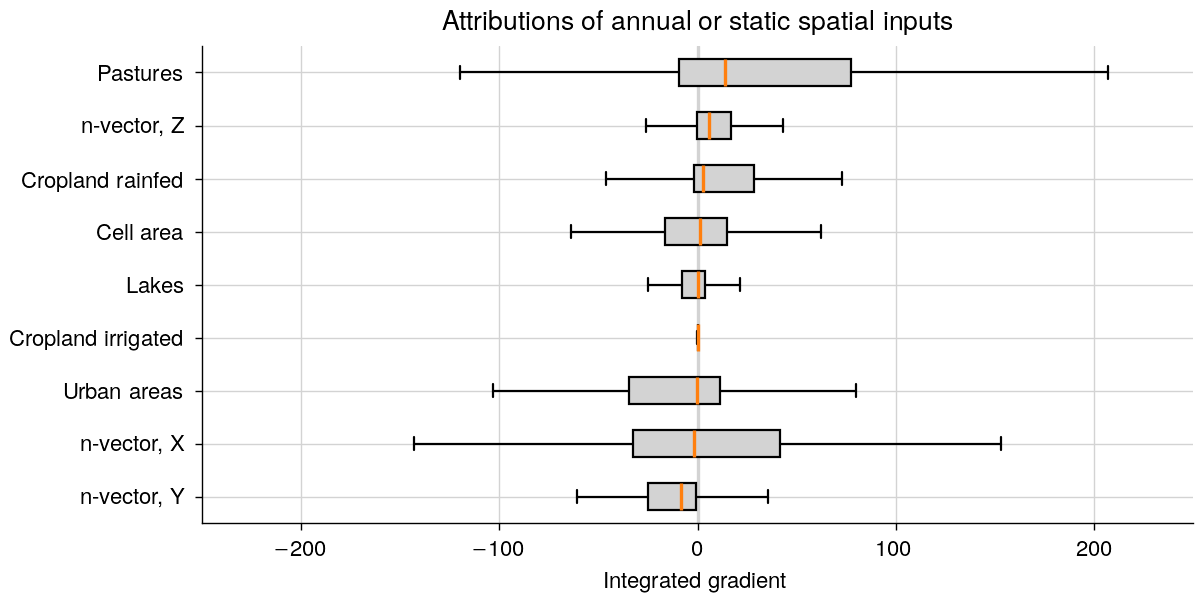

In [ ]:
data = att_m_mean
labels = dm._matrix_input_vars

height = (len(labels) + 3) / 4
fig, ax = plt.subplots(figsize=(6, height))
plot_attributions(data, labels, ax=ax)
ax.set(xlim=(-250, 250), title="Attributions of annual or static spatial inputs");

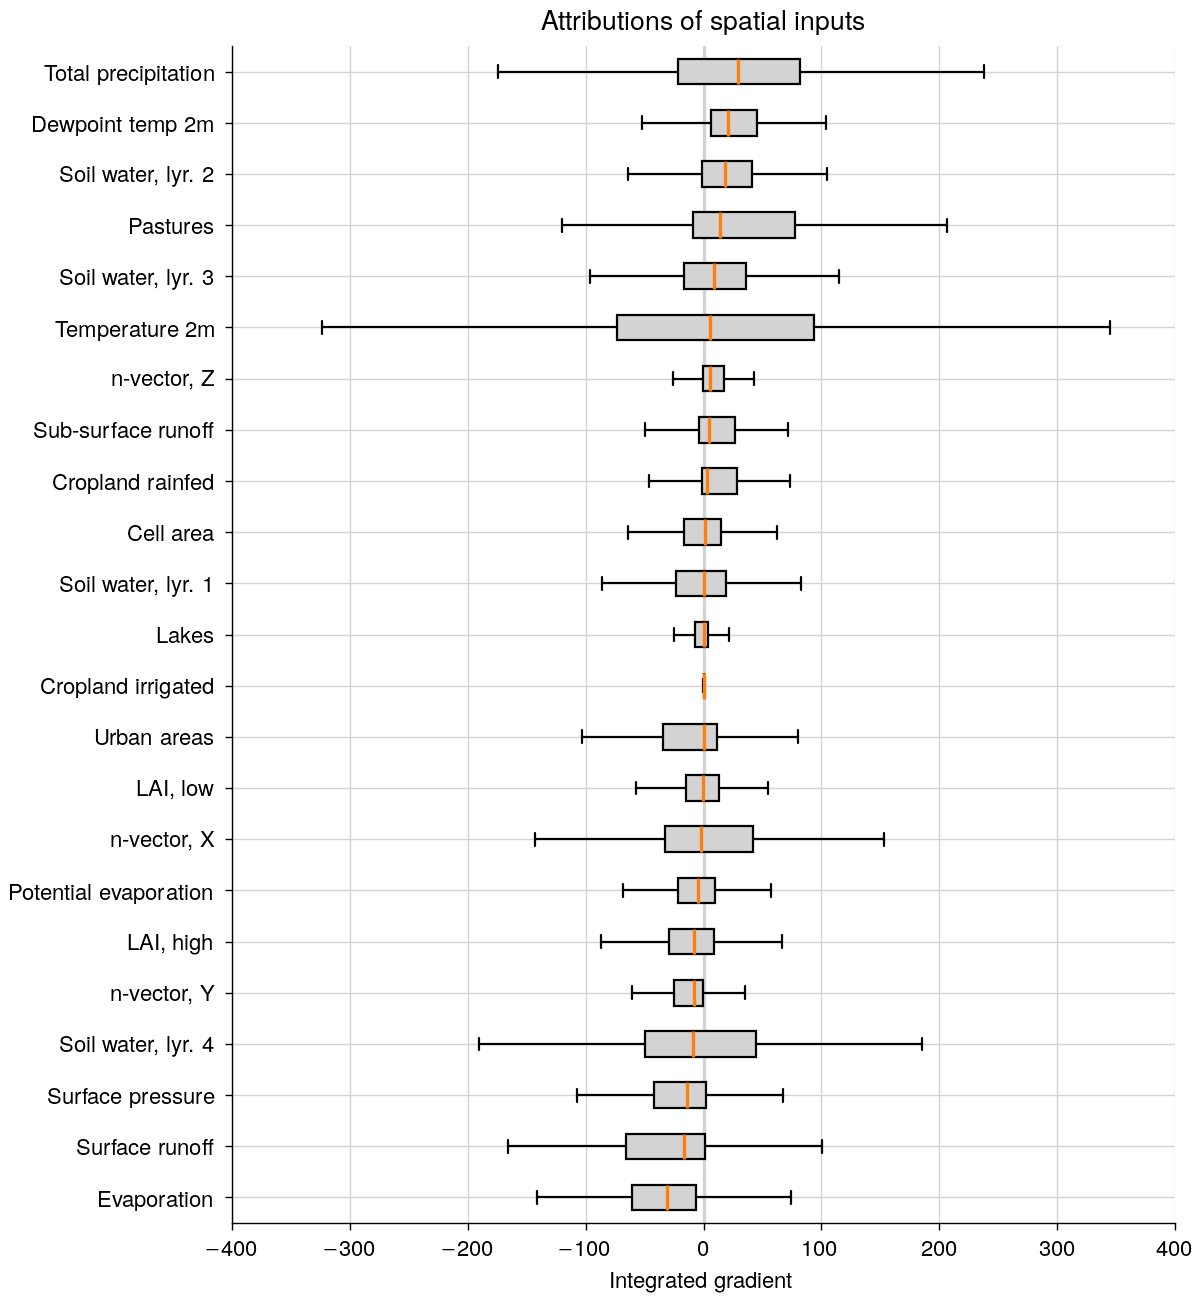

In [140]:
data = np.concat([att_t_mean, att_m_mean], axis=1)
labels = dm._tensor_input_vars + dm._matrix_input_vars

height = (len(labels) + 3) / 4
fig, ax = plt.subplots(figsize=(6, height))
plot_attributions(data, labels, ax=ax)
ax.set(xlim=(-400, 400), title="Attributions of spatial inputs");

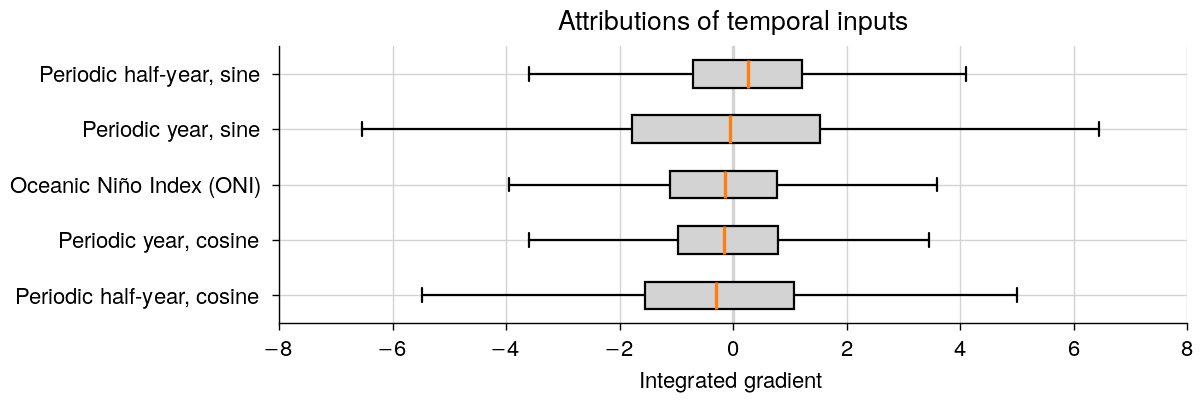

In [ ]:
data = att_v_mean
labels = dm._vector_input_vars

height = (len(labels) + 3) / 4
fig, ax = plt.subplots(figsize=(6, height))
plot_attributions(data, labels, ax=ax)
ax.set(xlim=(-8, 8), title="Attributions of temporal inputs");

## Violin plots

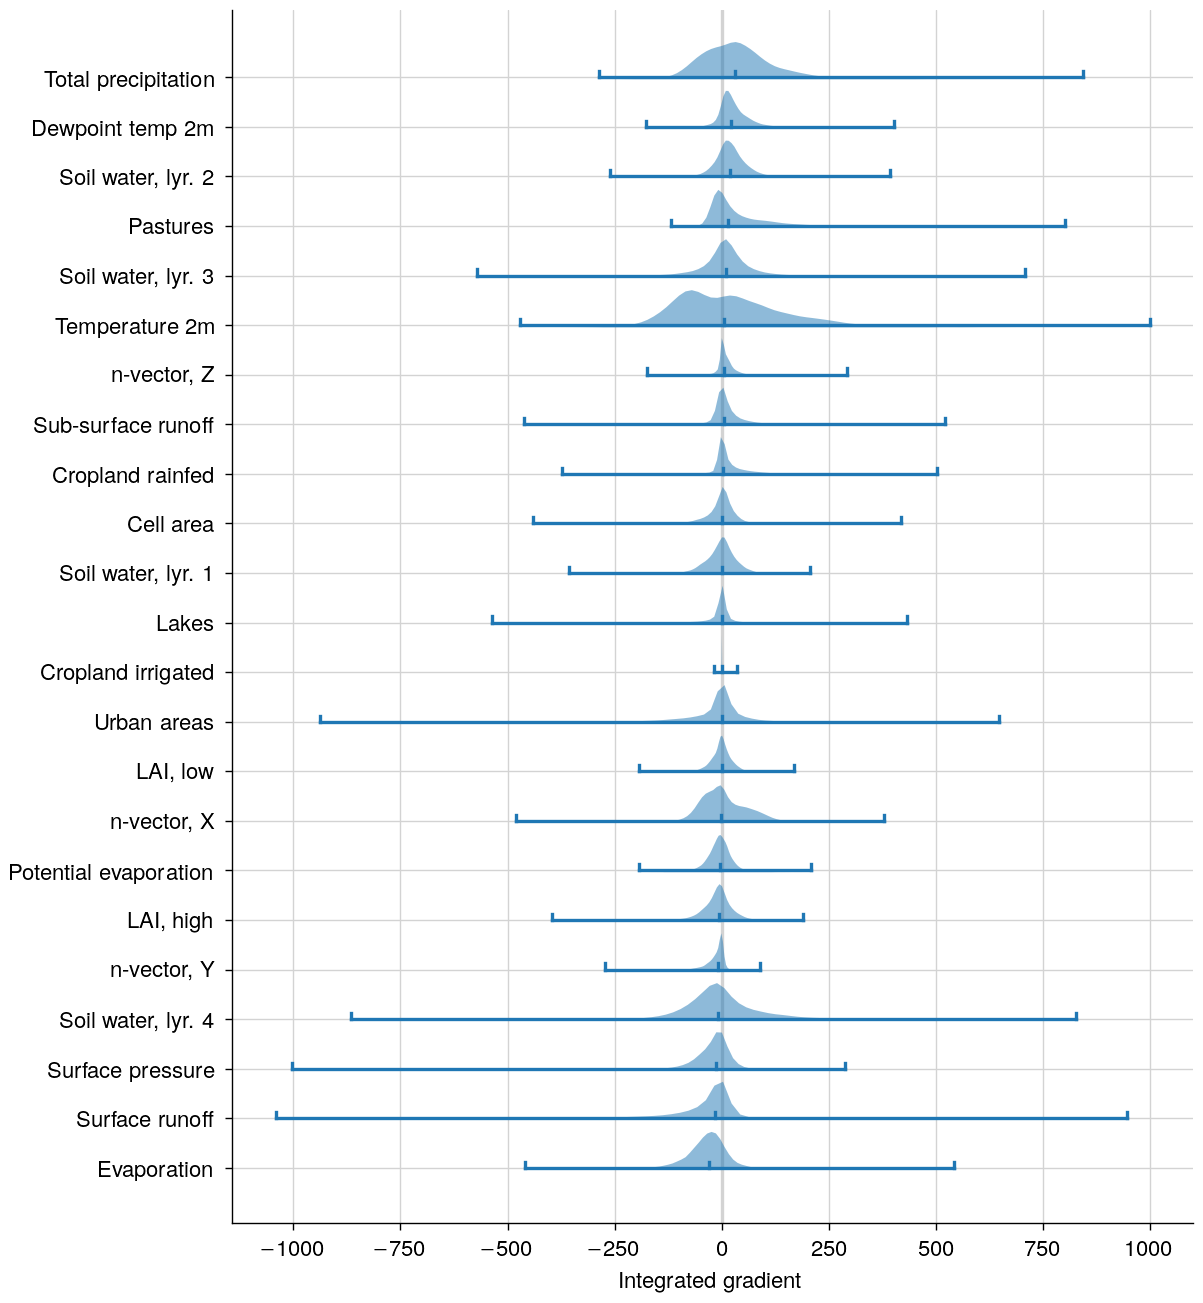

In [243]:
data = np.concat([att_t_mean, att_m_mean], axis=1)
labels = dm._tensor_input_vars + dm._matrix_input_vars
height = (len(labels) + 3) / 4
fig, ax = plt.subplots(figsize=(6, height))
SCALE_FACTOR = 3

medians = np.median(data, axis=0)
abs_medians = np.abs(medians)
order = np.argsort(medians)
data = data[:, order]
labels = [labels[i] for i in order]
labels = [rename[label] for label in labels]

ax.axvline(0, color="lightgray", linewidth=1.2, zorder=-100)
vplot = ax.violinplot(
    data,
    showextrema=True,
    showmedians=True,
    orientation="horizontal",
    side="high",
    # tick_labels=labels,
    # patch_artist=True,
)
for patch in vplot["bodies"]:
    patch.set(facecolor="tab:blue", edgecolor="None", alpha=0.5)
for patch in vplot["bodies"]:
    # enlarge each violin vertically by factor around its center
    for path in patch.get_paths():
        verts = path.vertices
        y = verts[:, 1]
        center = y.mean()
        verts[:, 1] = center + SCALE_FACTOR * (y - center)
    # #     path.vertices = verts
    patch.set(facecolor="tab:blue", edgecolor="None", alpha=0.5)

# vplot["cmedians"].set(color="black")

ax.set(
    yticks=np.arange(1, len(labels) + 1),
    yticklabels=labels,
    xlabel="Integrated gradient",
    ylabel=None,
)
ax.axes.grid()

## Bar charts

In [282]:
def plot_attributions_bar(data: np.ndarray, labels: list[str], ax: plt.Axes) -> None:
    Y_END_BUFFER = 0.75
    abs_means = np.abs(data).mean(axis=0)
    order = np.argsort(abs_means)
    data = abs_means[order]
    labels = [labels[i] for i in order]
    labels = [rename[label] for label in labels]
    ax.barh(labels, data, height=0.7)
    ax.set(
        xlabel="mean(|Integrated gradient|)", ylim=(-Y_END_BUFFER, len(labels) - 1 + Y_END_BUFFER)
    )
    # remove ticks for categorical values
    ax.tick_params(axis="y", length=0)
    ax.xaxis.grid()

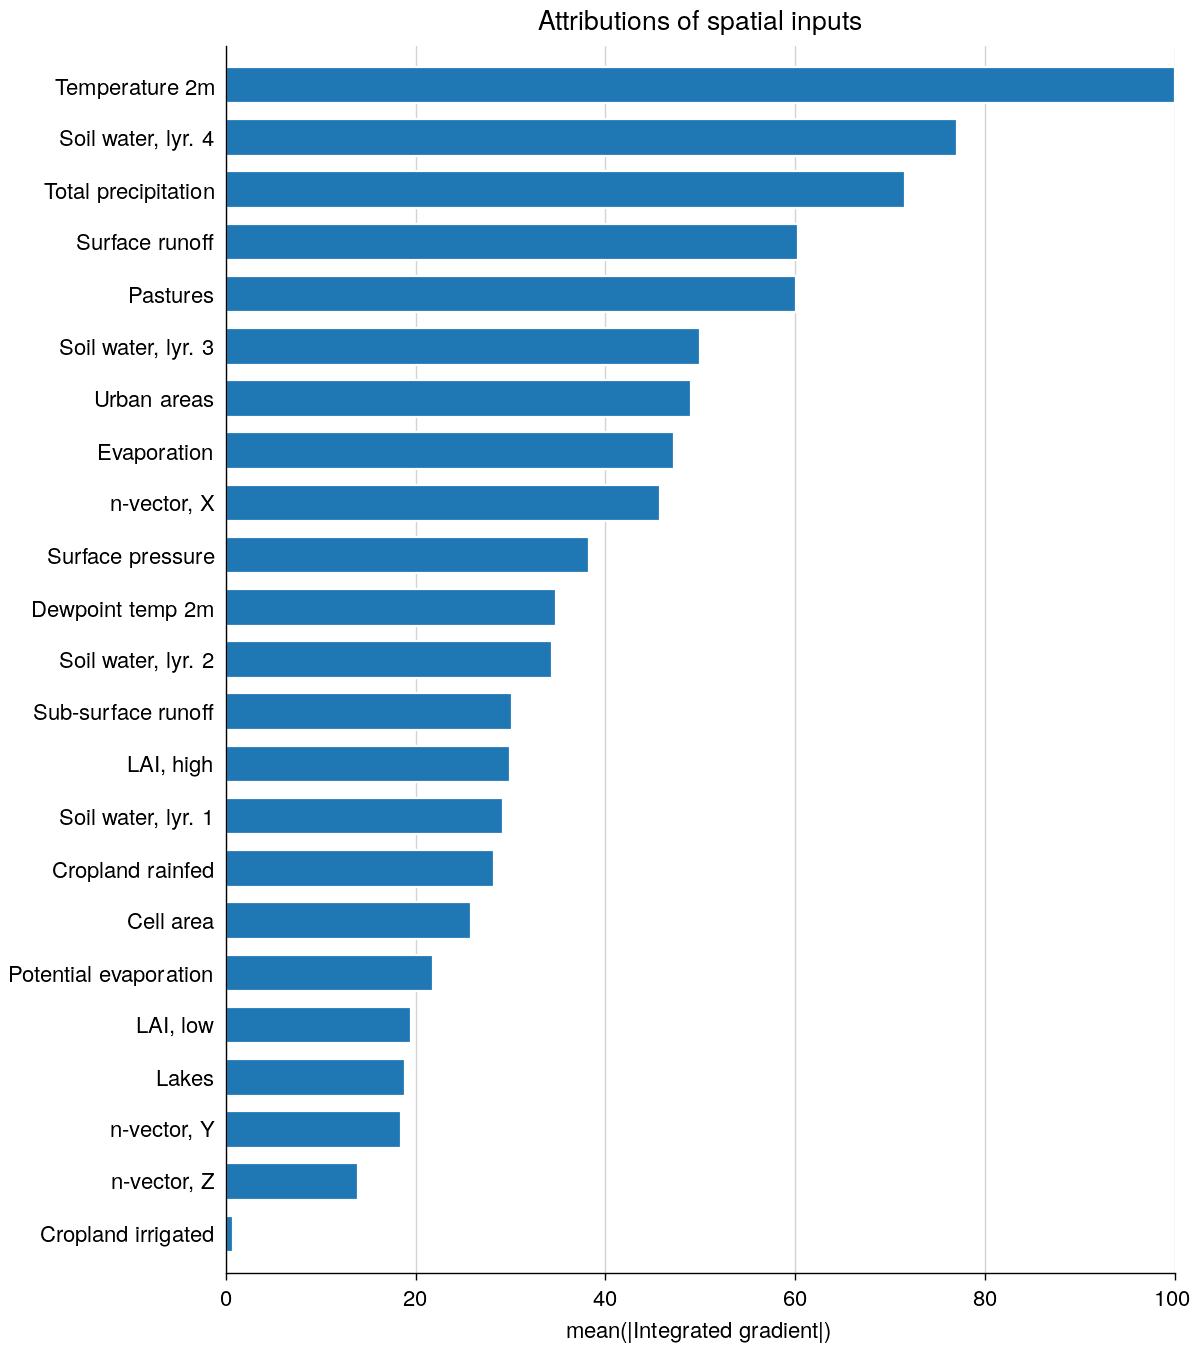

In [332]:
data = np.concat([att_t_mean, att_m_mean], axis=1)
labels = dm._tensor_input_vars + dm._matrix_input_vars
height = len(labels) / 4 + 1
fig, ax = plt.subplots(figsize=(6, height))
plot_attributions_bar(data, labels, ax)
ax.set(xlim=(0, 100), title="Attributions of spatial inputs");

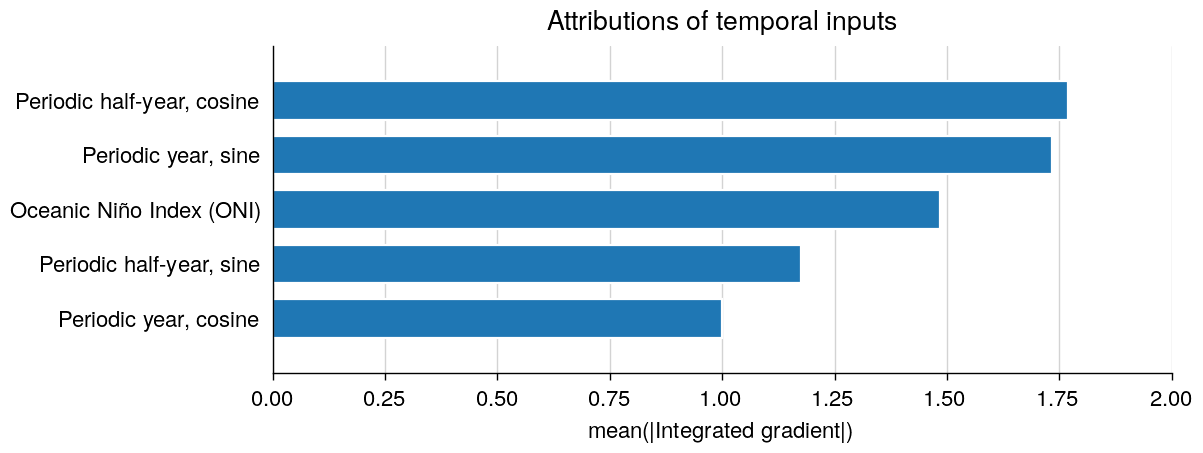

In [331]:
data = att_v_mean
labels = dm._vector_input_vars
height = len(labels) / 4 + 1
fig, ax = plt.subplots(figsize=(6, height))
plot_attributions_bar(data, labels, ax)
ax.set(xlim=(0, 2), ylim=(-1, len(labels)), title="Attributions of temporal inputs");

## Tables

In [269]:
# Get dataframe with attribution mean and std
def get_attribution_df(attribution_batch: np.ndarray, feature_names: list[str]) -> pd.DataFrame:
    medians = np.median(attribution_batch, 0)
    stds = attribution_batch.std(0)
    return pd.DataFrame(data={"median": medians, "std": stds}, index=feature_names).sort_values(
        "median", ascending=False
    )

In [272]:
# Create pandas Series
series_att_t_abs = get_attribution_df(att_t_mean, dm._tensor_input_vars)
series_att_m_abs = get_attribution_df(att_m_mean, dm._matrix_input_vars)
series_att_v_abs = get_attribution_df(att_v_mean, dm._vector_input_vars)

print("Tensor inputs:")
print(series_att_t_abs)
print("\nMatrix inputs:")
print(series_att_m_abs)
print("\nVector inputs:")
print(series_att_v_abs)

Tensor inputs:
                median         std
era5_tp      29.461239   91.536263
era5_d2m     21.043774   39.543491
era5_swvl2   17.911388   42.766811
era5_swvl3    8.608564   81.398994
era5_t2m      5.712846  128.580200
era5_ssro     4.571557   54.205521
era5_swvl1    0.145010   40.861034
era5_lai_lv  -0.791956   27.163967
era5_pev     -5.067490   29.372814
era5_lai_hv  -7.841125   42.616386
era5_swvl4   -8.763237  117.131187
era5_sp     -14.410374   66.169014
era5_sro    -16.653038   96.737892
era5_e      -31.091444   53.716721

Matrix inputs:
                       median        std
pastures            13.703150  91.130852
nvec_z               5.552595  19.159399
cropland_rainfed     2.865617  48.706371
cell_area            1.406171  40.553082
lakes                0.057726  40.238808
cropland_irrigated   0.000000   2.323722
urbanareas          -0.048290  87.570282
nvec_x              -1.974054  62.823002
nvec_y              -8.343430  25.192848

Vector inputs:
             media